COLUMNS IN DATASET:
Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard',
       'Parents/Children Aboard', 'Fare'],
      dtype='object')

FIRST 5 ROWS
   Survived  Pclass                                               Name  \
0         0       3                             Mr. Owen Harris Braund   
1         1       1  Mrs. John Bradley (Florence Briggs Thayer) Cum...   
2         1       3                              Miss. Laina Heikkinen   
3         1       1        Mrs. Jacques Heath (Lily May Peel) Futrelle   
4         0       3                            Mr. William Henry Allen   

      Sex   Age  Siblings/Spouses Aboard  Parents/Children Aboard     Fare  
0    male  22.0                        1                        0   7.2500  
1  female  38.0                        1                        0  71.2833  
2  female  26.0                        0                        0   7.9250  
3  female  35.0                        1                        0  53.

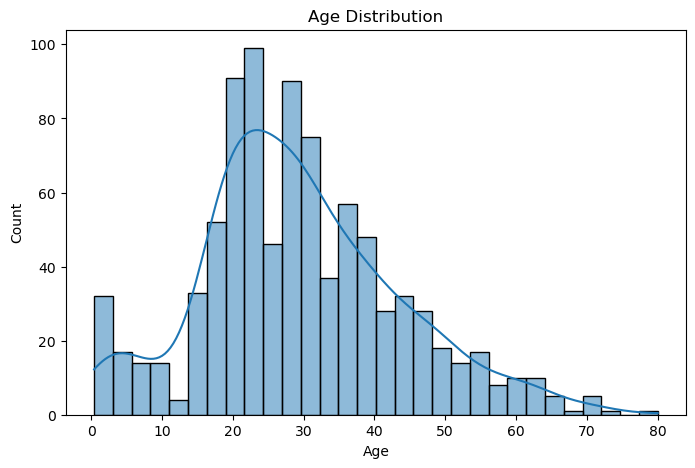

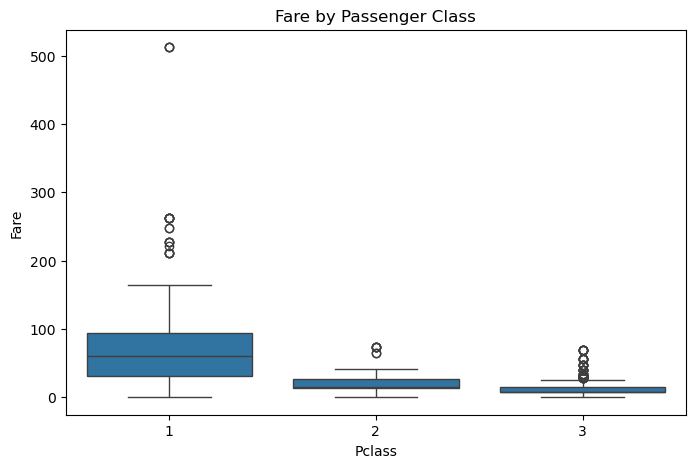

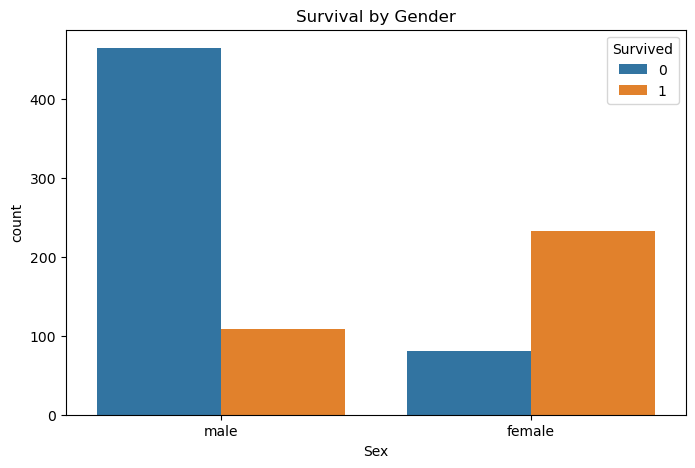

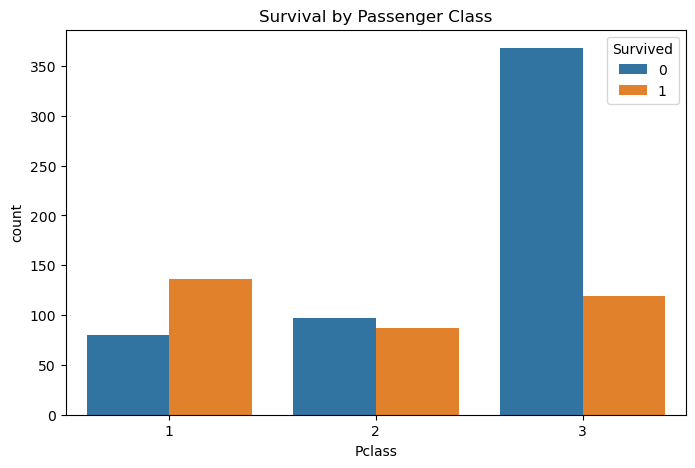

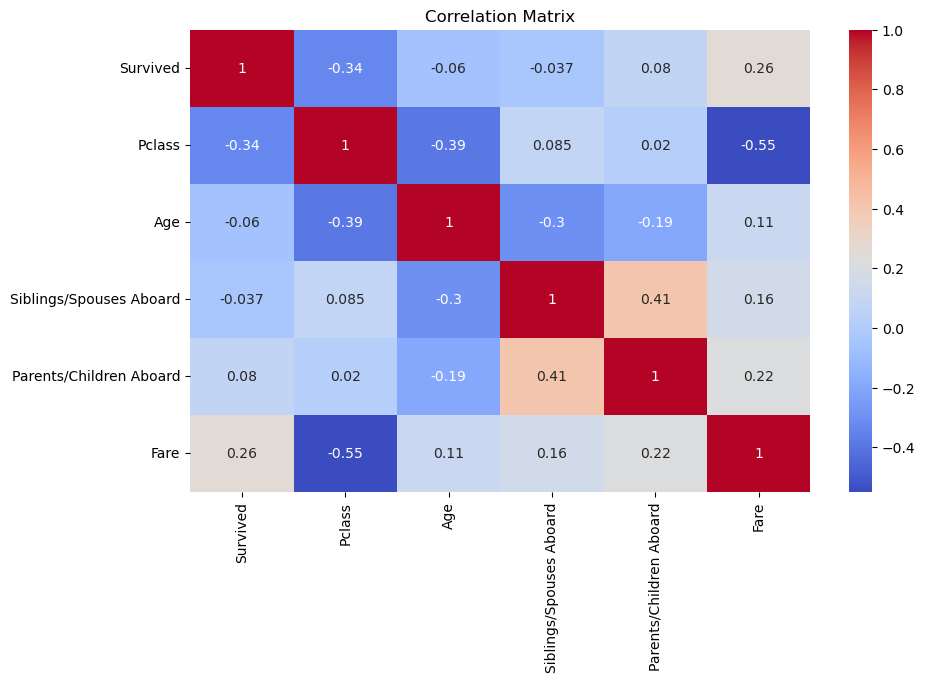


SURVIVAL PERCENTAGE BY CLASS
Survived          0          1
Pclass                        
1         37.037037  62.962963
2         52.717391  47.282609
3         75.564682  24.435318


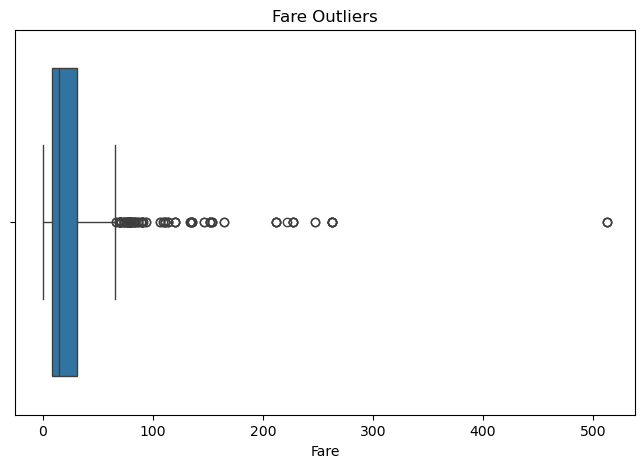


NUMBER OF FARE OUTLIERS
20


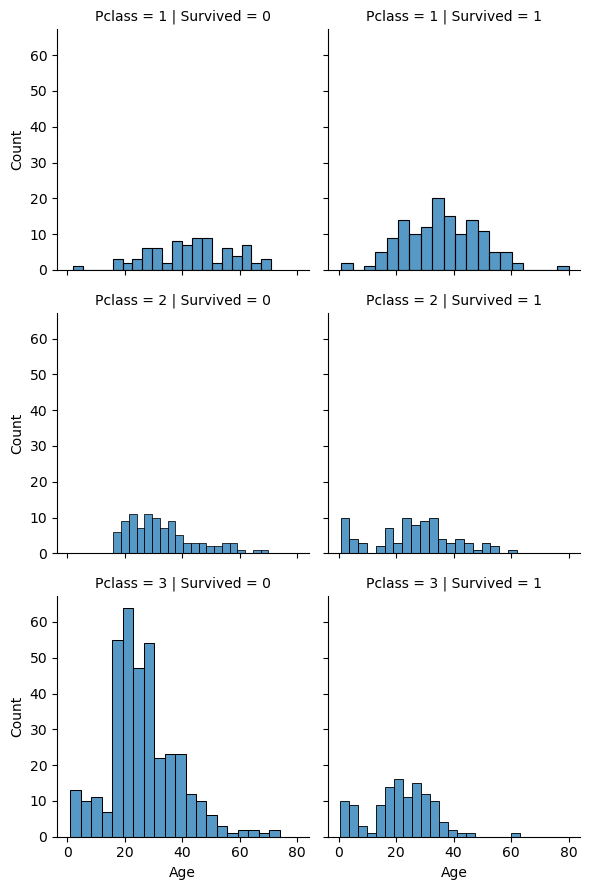

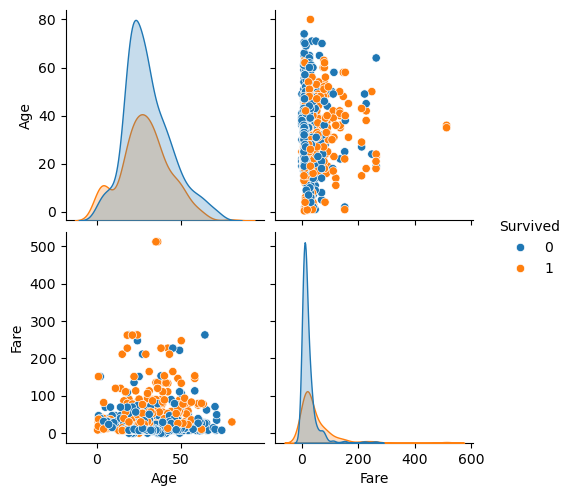


FINAL OBSERVATIONS

1. Female passengers survived more than males.

2. First-class passengers had higher survival rates.

3. Third-class passengers had lower survival rates.

4. Younger passengers had better survival chances.

5. Fare and survival are positively related.

6. Passenger class strongly affected survival.


CONCLUSION

Titanic EDA successfully analyzed survival patterns
using statistical analysis and visualization.

Techniques used:
- Data Cleaning
- Missing Value Handling
- Visualization
- Correlation Analysis
- Outlier Detection
- Statistical Summary

Python libraries like Pandas, Seaborn, and Matplotlib
helped understand passenger survival behavior.



In [2]:
# =========================================
# TITANIC EDA PROJECT - FULL WORKING CODE
# =========================================

# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# =========================================
# STEP 1: LOAD DATASET
# =========================================

df = pd.read_csv("titanic.csv")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Show column names
print("COLUMNS IN DATASET:")
print(df.columns)

# =========================================
# STEP 2: DISPLAY DATA
# =========================================

print("\nFIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nDATA TYPES")
print(df.dtypes)

print("\nMISSING VALUES")
print(df.isnull().sum())

# =========================================
# STEP 3: HANDLE MISSING VALUES
# =========================================

# Fill Age missing values
if 'Age' in df.columns:
    df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked missing values
if 'Embarked' in df.columns:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Fill Cabin missing values
if 'Cabin' in df.columns:
    df['Cabin'] = df['Cabin'].fillna('Unknown')

print("\nMISSING VALUES AFTER CLEANING")
print(df.isnull().sum())

# =========================================
# STEP 4: SUMMARY STATISTICS
# =========================================

print("\nSUMMARY STATISTICS")
print(df.describe(include='all'))

# =========================================
# STEP 5: AGE DISTRIBUTION
# =========================================

if 'Age' in df.columns:

    plt.figure(figsize=(8,5))

    sns.histplot(df['Age'], bins=30, kde=True)

    plt.title("Age Distribution")
    plt.xlabel("Age")
    plt.ylabel("Count")

    plt.show()

# =========================================
# STEP 6: FARE BY PASSENGER CLASS
# =========================================

if 'Pclass' in df.columns and 'Fare' in df.columns:

    plt.figure(figsize=(8,5))

    sns.boxplot(x='Pclass', y='Fare', data=df)

    plt.title("Fare by Passenger Class")

    plt.show()

# =========================================
# STEP 7: SURVIVAL BY GENDER
# =========================================

if 'Sex' in df.columns and 'Survived' in df.columns:

    plt.figure(figsize=(8,5))

    sns.countplot(x='Sex', hue='Survived', data=df)

    plt.title("Survival by Gender")

    plt.show()

# =========================================
# STEP 8: SURVIVAL BY PASSENGER CLASS
# =========================================

if 'Pclass' in df.columns and 'Survived' in df.columns:

    plt.figure(figsize=(8,5))

    sns.countplot(x='Pclass', hue='Survived', data=df)

    plt.title("Survival by Passenger Class")

    plt.show()

# =========================================
# STEP 9: CORRELATION MATRIX
# =========================================

plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

# =========================================
# STEP 10: CROSS TABULATION
# =========================================

if 'Pclass' in df.columns and 'Survived' in df.columns:

    survival_class = pd.crosstab(
        df['Pclass'],
        df['Survived'],
        normalize='index'
    ) * 100

    print("\nSURVIVAL PERCENTAGE BY CLASS")
    print(survival_class)

# =========================================
# STEP 11: OUTLIER DETECTION
# =========================================

if 'Fare' in df.columns:

    plt.figure(figsize=(8,5))

    sns.boxplot(x=df['Fare'])

    plt.title("Fare Outliers")

    plt.show()

# =========================================
# STEP 12: Z-SCORE METHOD
# =========================================

if 'Fare' in df.columns:

    z_scores = np.abs(stats.zscore(df['Fare']))

    outliers = df[z_scores > 3]

    print("\nNUMBER OF FARE OUTLIERS")
    print(len(outliers))

# =========================================
# STEP 13: FACET GRID
# =========================================

if 'Survived' in df.columns and 'Pclass' in df.columns and 'Age' in df.columns:

    g = sns.FacetGrid(
        df,
        col='Survived',
        row='Pclass',
        height=3
    )

    g.map(sns.histplot, 'Age', bins=20)

    plt.show()

# =========================================
# STEP 14: PAIRPLOT
# =========================================

pairplot_columns = []

for col in ['Age', 'Fare', 'Parch', 'Survived']:
    if col in df.columns:
        pairplot_columns.append(col)

if len(pairplot_columns) > 1 and 'Survived' in pairplot_columns:

    sns.pairplot(
        df[pairplot_columns],
        hue='Survived'
    )

    plt.show()

# =========================================
# STEP 15: FINAL OBSERVATIONS
# =========================================

print("\nFINAL OBSERVATIONS")

print("""
1. Female passengers survived more than males.

2. First-class passengers had higher survival rates.

3. Third-class passengers had lower survival rates.

4. Younger passengers had better survival chances.

5. Fare and survival are positively related.

6. Passenger class strongly affected survival.
""")

# =========================================
# STEP 16: CONCLUSION
# =========================================

print("\nCONCLUSION")

print("""
Titanic EDA successfully analyzed survival patterns
using statistical analysis and visualization.

Techniques used:
- Data Cleaning
- Missing Value Handling
- Visualization
- Correlation Analysis
- Outlier Detection
- Statistical Summary

Python libraries like Pandas, Seaborn, and Matplotlib
helped understand passenger survival behavior.
""")